# HOUSE PRICE PREDICTION MODEL

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [ ]:
df = pd.read_csv("hpp.csv")

In [ ]:
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


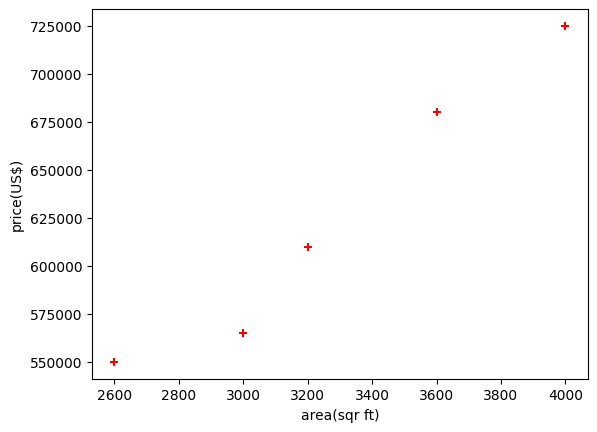

In [ ]:
%matplotlib inline
plt.xlabel('area(sqr ft)')
plt.ylabel('price(US$)')
plt.scatter(df.area,df.price,color = 'red',marker ='+')

In [ ]:
reg = linear_model.LinearRegression()
reg.fit(df[['area']],df.price)

LinearRegression()

In [ ]:
reg.predict([[3300]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([628715.75342466])

In [ ]:
reg.coef_

array([135.78767123])

In [ ]:
reg.intercept_

np.float64(180616.43835616432)

In [ ]:
135.78767123*3300+180616.43835616432

628715.7534151643

In [ ]:
# Multivariate Problem

In [ ]:
df = pd.read_csv("home price prediction MV.csv")

In [ ]:
df

,area,bedroom,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000


In [ ]:
df.bedroom.median()

3.5

In [ ]:
df.bedroom.fillna(3)

,bedroom
0,3.0
1,4.0
2,3.0
3,3.0
4,5.0


In [ ]:
df

,area,bedroom,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,NaN,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000


In [ ]:
df.bedroom = df.bedroom.fillna(df.bedroom.fillna(3))

In [ ]:
df

,area,bedroom,age,price
0,2600,3.0,20,550000
1,3000,4.0,15,565000
2,3200,3.0,18,610000
3,3600,3.0,30,595000
4,4000,5.0,8,760000


In [ ]:
reg = linear_model.LinearRegression()
reg.fit(df.drop('price',axis = 'columns'),df.price)

LinearRegression()

In [ ]:
reg.coef_

array([   137.25, -26025.  ,  -6825.  ])

In [ ]:
reg.intercept_

np.float64(383724.9999999998)

In [ ]:
reg.predict(([[3000,3,40]]))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([444400.])

In [ ]:
137.25*3000 + -26025.*3 + -6825.*40 + 383724.9999999998

444399.9999999998

In [ ]:
reg.predict([[2500,4,5]])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([588625.])

# HIRING EMPLOYEES MODEL


In [ ]:
df = pd.read_csv("hiring.csv")

In [ ]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [ ]:
df.experience = df.experience.fillna('Zero')

In [ ]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,Zero,8.0,9,50000
1,Zero,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,NaN,7,72000
7,eleven,7.0,8,80000


In [ ]:
print(df.columns)

Index(['experience', 'test_score(out of 10)', 'interview_score(out of 10)',
       'salary($)'],
      dtype='object')


In [ ]:
def convert_word_to_num(word):
    word_dict = {
        'zero': 0, 'one': 1, 'two': 2, 'three': 3, 'four': 4,
        'five': 5, 'six': 6, 'seven': 7, 'eight': 8, 'nine': 9,
        'ten': 10, 'eleven': 11, 'twelve': 12
    }

    if isinstance(word, str):
        return word_dict.get(word.lower(), 0)
    else:
        return 0

# Applying the function to the 'experience' column
df['experience'] = df['experience'].apply(convert_word_to_num)





In [ ]:
import math
median_test_score = math.floor(df['test_score(out of 10)'].mean())
median_test_score

7

In [ ]:
df['test_score(out of 10)'] = df['test_score(out of 10)'].fillna(median_test_score)
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,7.0,7,72000
7,11,7.0,8,80000


In [ ]:
# splitting the data into X and y
# creating instance of Linear Regression
# and applying Linear Regression
reg = linear_model.LinearRegression()
reg.fit(df[['experience','test_score(out of 10)','interview_score(out of 10)']],df['salary($)'])

LinearRegression()

In [ ]:
reg.predict([[2,9,6]])  #Predict salary for 2yr experience,9 test score and 6 interview score

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([53713.86677124])

In [ ]:
reg.predict([[12,10,10]]) #Predict salary for 12yr experience, 10 test score and 10 interview score

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([93747.79628651])

In [ ]:
#ASSIGNMENT END

In [ ]:
# DAY 4

# MELBOURNE HOUSING MODEL

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
import seaborn as sns

In [ ]:
dataset = pd.read_csv("Melbourne_housing_FULL.csv")

In [ ]:
dataset

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.80140,144.99580,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.79960,144.99840,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.80790,144.99340,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.81140,145.01160,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.80930,144.99440,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34852,Yarraville,13 Burns St,4,h,1480000.0,PI,Jas,24/02/2018,6.3,3013.0,...,1.0,3.0,593.0,NaN,NaN,Maribyrnong City Council,-37.81053,144.88467,Western Metropolitan,6543.0
34853,Yarraville,29A Murray St,2,h,888000.0,SP,Sweeney,24/02/2018,6.3,3013.0,...,2.0,1.0,98.0,104.0,2018.0,Maribyrnong City Council,-37.81551,144.88826,Western Metropolitan,6543.0
34854,Yarraville,147A Severn St,2,t,705000.0,S,Jas,24/02/2018,6.3,3013.0,...,1.0,2.0,220.0,120.0,2000.0,Maribyrnong City Council,-37.82286,144.87856,Western Metropolitan,6543.0
34855,Yarraville,12/37 Stephen St,3,h,1140000.0,SP,hockingstuart,24/02/2018,6.3,3013.0,...,NaN,NaN,NaN,NaN,NaN,Maribyrnong City Council,NaN,NaN,Western Metropolitan,6543.0


In [ ]:
dataset.nunique()

,0
Suburb,351
Address,34009
Rooms,12
Type,3
Price,2871
Method,9
SellerG,388
Date,78
Distance,215
Postcode,211


In [ ]:
cols_to_use = ['Suburb', 'Rooms', 'Type', 'Method', 'SellerG', 'Regionname', 'Propertycount',
               'Distance', 'CouncilArea', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'Price']

In [ ]:
dataset = dataset[cols_to_use]


In [ ]:
dataset

,Suburb,Rooms,Type,Method,SellerG,Regionname,Propertycount,Distance,CouncilArea,Bedroom2,Bathroom,Car,Landsize,BuildingArea,Price
0,Abbotsford,2,h,SS,Jellis,Northern Metropolitan,4019.0,2.5,Yarra City Council,2.0,1.0,1.0,126.0,NaN,NaN
1,Abbotsford,2,h,S,Biggin,Northern Metropolitan,4019.0,2.5,Yarra City Council,2.0,1.0,1.0,202.0,NaN,1480000.0
2,Abbotsford,2,h,S,Biggin,Northern Metropolitan,4019.0,2.5,Yarra City Council,2.0,1.0,0.0,156.0,79.0,1035000.0
3,Abbotsford,3,u,VB,Rounds,Northern Metropolitan,4019.0,2.5,Yarra City Council,3.0,2.0,1.0,0.0,NaN,NaN
4,Abbotsford,3,h,SP,Biggin,Northern Metropolitan,4019.0,2.5,Yarra City Council,3.0,2.0,0.0,134.0,150.0,1465000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34852,Yarraville,4,h,PI,Jas,Western Metropolitan,6543.0,6.3,Maribyrnong City Council,4.0,1.0,3.0,593.0,NaN,1480000.0
34853,Yarraville,2,h,SP,Sweeney,Western Metropolitan,6543.0,6.3,Maribyrnong City Council,2.0,2.0,1.0,98.0,104.0,888000.0
34854,Yarraville,2,t,S,Jas,Western Metropolitan,6543.0,6.3,Maribyrnong City Council,2.0,1.0,2.0,220.0,120.0,705000.0
34855,Yarraville,3,h,SP,hockingstuart,Western Metropolitan,6543.0,6.3,Maribyrnong City Council,NaN,NaN,NaN,NaN,NaN,1140000.0


In [ ]:
dataset.shape

(34857, 15)

In [ ]:
dataset.isna().sum()

,0
Suburb,0
Rooms,0
Type,0
Method,0
SellerG,0
Regionname,3
Propertycount,3
Distance,1
CouncilArea,3
Bedroom2,8217


In [ ]:
cols_to_fill_zero = ['Propertycount', 'Distance', 'CouncilArea', 'Bedroom2', 'Bathroom', 'Car', ]
dataset[cols_to_fill_zero] = dataset[cols_to_fill_zero].fillna(0)
dataset['Landsize'] = dataset['Landsize'].fillna(dataset.Landsize.median())
dataset['BuildingArea'] = dataset['BuildingArea'].fillna(dataset.BuildingArea.median())
dataset['Bathroom'] = dataset['Bathroom'].fillna(dataset.Bathroom.median())

/tmp/ipython-input-26-2851929890.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset[cols_to_fill_zero] = dataset[cols_to_fill_zero].fillna(0)
/tmp/ipython-input-26-2851929890.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['Landsize'] = dataset['Landsize'].fillna(dataset.Landsize.median())
/tmp/ipython-input-26-2851929890.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cave

In [ ]:
dataset.dropna(inplace=True)

/tmp/ipython-input-27-2639109627.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset.dropna(inplace=True)


In [ ]:
dataset.shape

(27244, 15)

In [ ]:
#Let's one hot encode the categorical features

In [ ]:
dataset = pd.get_dummies(dataset, drop_first=True)

In [ ]:
dataset.head()

,Rooms,Propertycount,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,Price,Suburb_Aberfeldie,...,CouncilArea_Moorabool Shire Council,CouncilArea_Moreland City Council,CouncilArea_Nillumbik Shire Council,CouncilArea_Port Phillip City Council,CouncilArea_Stonnington City Council,CouncilArea_Whitehorse City Council,CouncilArea_Whittlesea City Council,CouncilArea_Wyndham City Council,CouncilArea_Yarra City Council,CouncilArea_Yarra Ranges Shire Council
1,2,4019.0,2.5,2.0,1.0,1.0,202.0,136.0,1480000.0,False,...,False,False,False,False,False,False,False,False,True,False
2,2,4019.0,2.5,2.0,1.0,0.0,156.0,79.0,1035000.0,False,...,False,False,False,False,False,False,False,False,True,False
4,3,4019.0,2.5,3.0,2.0,0.0,134.0,150.0,1465000.0,False,...,False,False,False,False,False,False,False,False,True,False
5,3,4019.0,2.5,3.0,2.0,1.0,94.0,136.0,850000.0,False,...,False,False,False,False,False,False,False,False,True,False
6,4,4019.0,2.5,3.0,1.0,2.0,120.0,142.0,1600000.0,False,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
X = dataset.drop('Price',axis=1)
y = dataset['Price']

In [ ]:
from sklearn.model_selection import train_test_split
train_X,test_X,train_y,test_y = train_test_split(X,y,test_size=0.3,random_state=2)

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(train_X,train_y)

In [ ]:
reg.score(test_X,test_y)

0.14829692023923957

In [ ]:
reg.score(train_X,train_y)

0.682698043825755

In [ ]:
#Using Lasso (L1 Regularized model) Regression Model

In [ ]:
from sklearn import linear_model

In [ ]:
lasso_reg = linear_model.Lasso(alpha=50,max_iter=100,tol=0.1)
lasso_reg.fit(train_X,train_y)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.327e+15, tolerance: 7.963e+14
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=50, max_iter=100, tol=0.1)

In [ ]:
lasso_reg.score(test_X,test_y)

0.6662000730603173

In [ ]:
lasso_reg.score(train_X,train_y)

0.6765741051027789

In [ ]:
from sklearn.linear_model import Ridge  #L2 Regularization

In [ ]:
ridge_reg = Ridge(alpha=50,max_iter=100,tol=0.1)
ridge_reg.fit(train_X,train_y)

Ridge(alpha=50, max_iter=100, tol=0.1)

In [ ]:
ridge_reg.score(test_X,test_y)

0.6670553260220173

In [ ]:
ridge_reg.score(train_X,train_y)

0.6622234991357131

# INSURANCE PREDICTION MODEL

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
df = pd.read_csv("insurance_data.csv")

In [ ]:
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


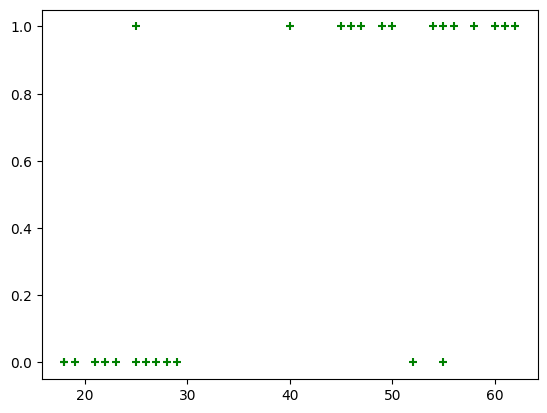

In [ ]:
plt.scatter(df.age,df.bought_insurance,marker='+',color='green')

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_X,test_X,train_y,test_y = train_test_split(df[['age']],df.bought_insurance,train_size=0.8,random_state=5)

In [ ]:
test_X

,age
23,45
19,18
2,47
11,28
20,21
10,18


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
model.fit(train_X,train_y)

LogisticRegression()

In [ ]:
test_X

,age
23,45
19,18
2,47
11,28
20,21
10,18


In [ ]:
y_predicted = model.predict(test_X)

In [ ]:
y_predicted

array([1, 0, 1, 0, 0, 0])

In [ ]:
model.predict_proba(test_X)

array([[0.33463021, 0.66536979],
       [0.91929511, 0.08070489],
       [0.28527642, 0.71472358],
       [0.78197384, 0.21802616],
       [0.88954752, 0.11045248],
       [0.91929511, 0.08070489]])

In [ ]:
model.score(test_X,test_y)

1.0

In [ ]:
y_predicted

array([1, 0, 1, 0, 0, 0])

# HR COMMA SEPRATED MODEL

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
import seaborn as sns

In [ ]:
df = pd.read_csv("HR_comma_sep.csv")

In [ ]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
df.nunique()

,0
satisfaction_level,92
last_evaluation,65
number_project,6
average_montly_hours,215
time_spend_company,8
Work_accident,2
left,2
promotion_last_5years,2
Department,10
salary,3


In [ ]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [ ]:
cols_to_use = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours',
              'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years',
              'Department', 'salary']


In [ ]:
df = df[cols_to_use]

In [ ]:
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [ ]:
df.shape

(14999, 10)

In [ ]:
df.isna().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [ ]:
df.left

,left
0,1
1,1
2,1
3,1
4,1
...,...
14994,1
14995,1
14996,1
14997,1


<Axes: xlabel='salary'>

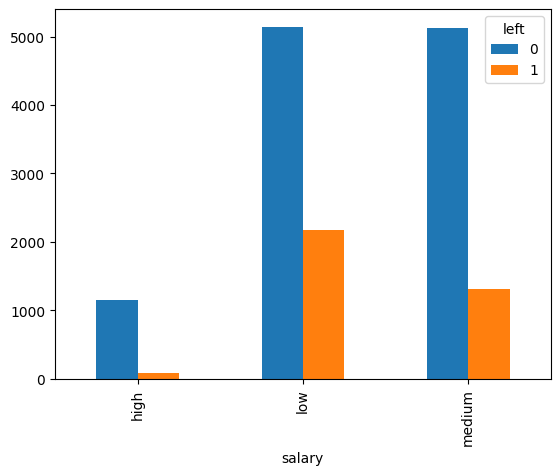

In [ ]:
pd.crosstab(df.salary,df.left).plot(kind='bar')

<Axes: xlabel='Department'>

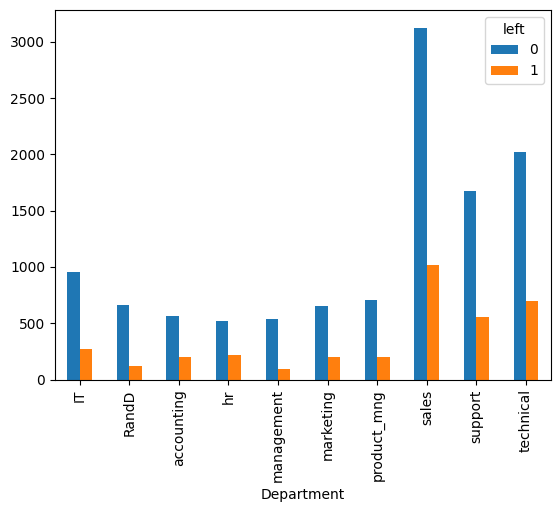

In [ ]:
pd.crosstab(df.Department,df.left).plot(kind='bar')

In [ ]:
df_new = df[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]
df_new.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


In [ ]:
dummy_salary = pd.get_dummies(df_new.salary,prefix='salary')
dummy_salary.head()

,salary_high,salary_low,salary_medium
0,False,True,False
1,False,False,True
2,False,False,True
3,False,True,False
4,False,True,False


In [ ]:
df_new_with_dummy = pd.concat([df_new,dummy_salary],axis='columns')
df_new_with_dummy.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary,salary_high,salary_low,salary_medium
0,0.38,157,0,low,False,True,False
1,0.80,262,0,medium,False,False,True
2,0.11,272,0,medium,False,False,True
3,0.72,223,0,low,False,True,False
4,0.37,159,0,low,False,True,False


In [ ]:
df_new_with_dummy.drop('salary',axis='columns',inplace=True)
df_new_with_dummy.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False


In [ ]:
X = df_new_with_dummy
y = df.left

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
model.score(X_test,y_test)

0.7696666666666667

# LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
digits = load_digits()

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(digits.data,digits.target,test_size=0.3)

In [ ]:
lr = LogisticRegression(solver= 'liblinear',multi_class='ovr')
lr.fit(X_train,y_train)
lr.score(X_test,y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


0.9574074074074074

In [ ]:
svm = SVC(gamma='auto')
svm.fit(X_train,y_train)
svm.score(X_test,y_test)

0.45925925925925926

In [ ]:
rf =RandomForestClassifier(n_estimators=40)
rf.fit(X_train,y_train)
rf.score(X_test,y_test)


0.9796296296296296

In [ ]:
rf =RandomForestClassifier(n_estimators=250)
rf.fit(X_train,y_train)
rf.score(X_test,y_test)

0.9796296296296296

In [ ]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=3)
kf

KFold(n_splits=3, random_state=None, shuffle=False)

In [ ]:
for train_index,test_index in kf.split([1,2,3,4,5,6,7,8,9]):
  print(train_index,test_index)

[3 4 5 6 7 8] [0 1 2]
[0 1 2 6 7 8] [3 4 5]
[0 1 2 3 4 5] [6 7 8]


In [ ]:
def get_score(model,X_train,x_test,y_train,y_test):
  model.fit(X_train,y_train)
  return model.score(X_test,y_test)

In [ ]:
from sklearn.model_selection import StratifiedKFold
folds = StratifiedKFold(n_splits=3)

scores_logistic = []
scores_svm = []
scores_rf = []

for train_index, test_index in folds.split(digits.data,digits.target):
    X_train, X_test, y_train, y_test = digits.data[train_index], digits.data[test_index], \
                                       digits.target[train_index], digits.target[test_index]
    scores_logistic.append(get_score(LogisticRegression(solver='liblinear',multi_class='ovr'), X_train,X_test,y_train,y_test))
    scores_svm.append(get_score(SVC(gamma='auto'),X_train,X_test,y_train,y_test))
    scores_rf.append(get_score(RandomForestClassifier(n_estimators=40),X_train,X_test,y_train,y_test))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
 scores_logistic

[0.8948247078464107, 0.9532554257095158, 0.9098497495826378]

In [ ]:
scores_svm

[0.3806343906510851, 0.41068447412353926, 0.5125208681135225]

In [ ]:
scores_rf

[0.9265442404006677, 0.9532554257095158, 0.9232053422370617]

In [ ]:
#cross_val_score Function

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
#Logistic regression model performance using cross_val_score

In [ ]:
cross_val_score(LogisticRegression(solver = 'liblinear',multi_class='ovr'),digits.data,digits.target,cv=3)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


array([0.89482471, 0.95325543, 0.90984975])

In [ ]:
#SVM model performance using cross_val_score

In [ ]:
cross_val_score(SVC(gamma='auto'),digits.data,digits.target,cv=3)

array([0.38063439, 0.41068447, 0.51252087])

In [ ]:
#random forest performance using cross val score

In [ ]:
cross_val_score(RandomForestClassifier(n_estimators=40),digits.data,digits.target,cv=3)

array([0.92988314, 0.94323873, 0.92654424])

In [ ]:
#Parameter Tunning using k fold cross validation

In [ ]:
scores1 = cross_val_score(RandomForestClassifier(n_estimators=5),digits.data,digits.target,cv=10)
np.average(scores1)

np.float64(0.8759031657355681)

In [ ]:
scores2 = cross_val_score(RandomForestClassifier(n_estimators=20),digits.data,digits.target,cv=10)
np.average(scores2)

np.float64(0.9432371198013655)

In [ ]:
scores3 = cross_val_score(RandomForestClassifier(n_estimators=30),digits.data,digits.target,cv=10)
np.average(scores3)

np.float64(0.9454593420235877)

In [ ]:
scores4 = cross_val_score(RandomForestClassifier(n_estimators=40),digits.data,digits.target,cv=10)
np.average(scores4)

np.float64(0.9454562383612662)